**Environment Setup and Library Import**
Installs the required libraries and mounts Google Drive to access dataset files within the Colab environment.

In [1]:
!pip install pandas scikit-learn matplotlib seaborn --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Extraction and Loading**
Extracts the dataset from a ZIP file stored in Google Drive, reads the first available CSV file into a pandas DataFrame, and displays the number and names of columns.

In [2]:
import pandas as pd
import os
import zipfile

# path
zip_path = '/content/drive/MyDrive/Engneer/CSV.zip'
extract_path = '/content/dataset'

# Decompressed
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Decompressed successfully.\n")

csv_files = [file for file in os.listdir(extract_path) if file.endswith('.csv')]

if csv_files:
    print(" Found CSV files:")
    for idx, file in enumerate(csv_files):
        print(f"{idx}: {file}")

    selected_idx = int(input("\nEnter the number of the CSV file you want to load: "))
    dataset_path = os.path.join(extract_path, csv_files[selected_idx])

    df = pd.read_csv(dataset_path, low_memory=False)

    print(f"\n Loaded the full file. Shape: {df.shape}")
    print(f" Columns list: {df.columns.tolist()}")

else:
    print("No CSV files found.")


Decompressed successfully.

 Found CSV files:
0: feature_vectors_syscalls_frequency_5_Cat.csv
1: feature_vectors_static.csv
2: syscall_unique.csv
3: feature_vectors_syscallsbinders_frequency_5_Cat.csv

Enter the number of the CSV file you want to load: 0

 Loaded the full file. Shape: (11598, 140)
 Columns list: ['__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 'accept', 'access', 'bind', 'brk', 'capset', 'chdir', 'chmod', 'chown32', 'clock_getres', 'clock_gettime', 'clone', 'close', 'connect', 'dup', 'dup2', 'epoll_create', 'epoll_ctl', 'epoll_wait', 'eventfd2', 'execve', 'exit', 'exit_group', 'faccessat', 'fchmod', 'fchown32', 'fcntl', 'fcntl64', 'fdatasync', 'flock', 'fork', 'fstat64', 'fstatfs64', 'fsync', 'ftruncate', 'ftruncate64', 'futex', 'getcwd', 'getdents64', 'getegid32', 'geteuid32', 'getgid32', 'getgroups32', 'getpeername', 'getpgid', 'getpid', 'getppid', 'getpriority', 'getresgid32', 'getresuid32', 'getrusage', 'getsockname', 'getsockopt', 'gettid', 'ge

**Selecting and Previewing Key Columns**
Verifies the existence of specific columns (socket, connect, open) in the dataset and displays the first 10 values for initial inspection.

In [3]:
# Specify the required columns
columns_of_interest = ['socket', 'connect', 'open']

# Verify that the columns exist.
missing_cols = [col for col in columns_of_interest if col not in df.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
# Display the first 10 values ​​for the required columns
    print(df[columns_of_interest].head(10))

   socket  connect   open
0     7.0      7.0   28.0
1    21.0     17.0  301.0
2    14.0     14.0   56.0
3     3.0      3.0   82.0
4    19.0     13.0   60.0
5     1.0      1.0   22.0
6     1.0      1.0   23.0
7     2.0      2.0  352.0
8     1.0      1.0   22.0
9    13.0     13.0   58.0


**Data Transformation and Label Creation**
Transforms selected features into binary values based on defined thresholds and creates a malicious label indicating potential harmful behavior when multiple thresholds are exceeded.

In [4]:
df_transformed = df[['socket', 'connect', 'open']].copy()

# apply the thresholds we obtained from the analysis.
df_transformed['socket'] = df_transformed['socket'].apply(lambda x: 1 if x > 10 else 0)
df_transformed['connect'] = df_transformed['connect'].apply(lambda x: 1 if x > 10 else 0)
df_transformed['open'] = df_transformed['open'].apply(lambda x: 1 if x > 500 else 0)

# create a 'malicious' column
# If two or more conditions are met -> consider it malicious
df_transformed['malicious'] = df_transformed[['socket', 'connect', 'open']].sum(axis=1).apply(lambda x: 1 if x >= 2 else 0)

# print the first ten rows to make sure
print(df_transformed.head(20))


    socket  connect  open  malicious
0        0        0     0          0
1        1        1     0          1
2        1        1     0          1
3        0        0     0          0
4        1        1     0          1
5        0        0     0          0
6        0        0     0          0
7        0        0     0          0
8        0        0     0          0
9        1        1     0          1
10       0        0     0          0
11       0        0     0          0
12       1        1     0          1
13       0        0     0          0
14       0        0     0          0
15       0        0     0          0
16       0        0     0          0
17       0        0     0          0
18       0        0     0          0
19       1        1     0          1


**Dataset Cleaning and Splitting**
Cleans the dataset by removing any missing values, separates features from labels, and splits the data into training (70%), validation (15%), and testing (15%) sets while maintaining class balance.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

expected_columns = ['socket', 'connect', 'open', 'malicious']
missing_cols = [col for col in expected_columns if col not in df.columns]

if missing_cols:
    print(f"Missing columns in the dataset: {missing_cols}")
else:
    print("All expected columns are available.")

# remove any row that has missing data (as a precaution)
df_cleaned = df_transformed.dropna(subset=expected_columns)

print(f" Dataset cleaned. New shape: {df_cleaned.shape}")

# Separate features from purpose
X = df_cleaned[['socket', 'connect', 'open']]
y = df_cleaned['malicious']


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# We divide the timer into 15% verification and 15% testing.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Missing columns in the dataset: ['malicious']
 Dataset cleaned. New shape: (11598, 4)
Train size: 8118
Validation size: 1740
Test size: 1740


**Injecting Noise into the Training Set**
Adds a small amount of random noise to the training data by flipping feature values (0 to 1 or 1 to 0) for a small fraction of samples to introduce controlled variability and prevent overfitting.

In [6]:
X_train_noisy = X_train.copy()

# select a small percentage of the data to add noise to.
noise_fraction = 0.30

n_noisy_samples = int(noise_fraction * X_train_noisy.shape[0])

# select random samples.
np.random.seed(42)
noisy_indices = np.random.choice(X_train_noisy.index, size=n_noisy_samples, replace=False)

# Randomly noise values ​​(replace 0 with 1 or 1 with 0)
for idx in noisy_indices:
    feature_to_flip = np.random.choice(X_train_noisy.columns)
    X_train_noisy.loc[idx, feature_to_flip] = 1 - X_train_noisy.loc[idx, feature_to_flip]

print(f"Added noise to {n_noisy_samples} samples.")


Added noise to 2435 samples.


**Building Initial Decision Trees**
Generates an ensemble of 80 Decision Trees using bootstrap sampling on the noisy training data to create diverse base classifiers for the improved Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Building a slightly weaker Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='entropy',
    random_state=42
)

# Train
model.fit(X_train_noisy, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1202    0]
 [   0  538]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1202
           1       1.00      1.00      1.00       538

    accuracy                           1.00      1740
   macro avg       1.00      1.00      1.00      1740
weighted avg       1.00      1.00      1.00      1740



**Evaluating Decision Trees Using Validation Samples**
Evaluates each Decision Tree on three different resampled validation sets and computes the average accuracy to assess tree performance

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

# Random Forest
trees = model.estimators_


X_val_1, y_val_1 = resample(X_val, y_val, replace=False, random_state=1)
X_val_2, y_val_2 = resample(X_val, y_val, replace=False, random_state=2)
X_val_3, y_val_3 = resample(X_val, y_val, replace=False, random_state=3)

tree_accuracies = []


for idx, tree in enumerate(trees):
    acc1 = accuracy_score(y_val_1, tree.predict(X_val_1))
    acc2 = accuracy_score(y_val_2, tree.predict(X_val_2))
    acc3 = accuracy_score(y_val_3, tree.predict(X_val_3))
    avg_acc = (acc1 + acc2 + acc3) / 3
    tree_accuracies.append(avg_acc)

print(f"Evaluated {len(tree_accuracies)} trees with average accuracies.")



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

Evaluated 100 trees with average accuracies.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

**Computing Correlation Matrix Between Trees**
dot product correlation matrix to measure the similarity between trees.

In [9]:
from sklearn.tree import _tree

# (binary feature presence)
def extract_features_from_tree(tree, n_features):
    indicator = np.zeros(n_features)
    tree_ = tree.tree_
    features = tree_.feature
    for feature in features:
        if feature >= 0:
            indicator[feature] = 1
    return indicator

tree_vectors = [extract_features_from_tree(tree, X_train.shape[1]) for tree in trees]

# calculate the similarity dot product for each pair of trees.
correlation_matrix = np.zeros((len(tree_vectors), len(tree_vectors)))

for i in range(len(tree_vectors)):
    for j in range(i + 1, len(tree_vectors)):
        dot_product = np.dot(tree_vectors[i], tree_vectors[j])
        correlation_matrix[i, j] = dot_product
        correlation_matrix[j, i] = dot_product

print(f"Correlation matrix created. Shape: {correlation_matrix.shape}")


Correlation matrix created. Shape: (100, 100)


**Threshold Selection via Grid Search**
maximizes validation accuracy by filtering out highly similar trees.

In [10]:
best_threshold = None
best_accuracy = 0
thresholds = np.arange(10, 30, 2)

results = []

for threshold in thresholds:
    # determine which pairs are too similar
    to_delete = set()
    for i in range(len(tree_accuracies)):
        for j in range(i + 1, len(tree_accuracies)):
            if correlation_matrix[i, j] > threshold:
                # delete the weaker of the two
                if tree_accuracies[i] < tree_accuracies[j]:
                    to_delete.add(i)
                else:
                    to_delete.add(j)

    # build a temporary Random Forest
    selected_indices = [i for i in range(len(trees)) if i not in to_delete]
    selected_trees = [trees[i] for i in selected_indices]

   #Validation
    val_preds = []
    for x in X_val.values:
        votes = [tree.predict(pd.DataFrame([x], columns=X_val.columns))[0] for tree in selected_trees]
        majority_vote = max(set(votes), key=votes.count)
        val_preds.append(majority_vote)

    acc = accuracy_score(y_val, val_preds)
    results.append((threshold, acc))

    #save the best result
    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = threshold

print(f"Best threshold found: {best_threshold} with accuracy: {best_accuracy:.4f}")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.1

Best threshold found: 10 with accuracy: 1.0000


**Final Tree**

In [11]:
#delete similar trees based on the best threshold
to_delete_final = set()

for i in range(len(tree_accuracies)):
    for j in range(i + 1, len(tree_accuracies)):
        if correlation_matrix[i, j] > best_threshold:
            if tree_accuracies[i] < tree_accuracies[j]:
                to_delete_final.add(i)
            else:
                to_delete_final.add(j)

# define the final trees
final_indices = [i for i in range(len(trees)) if i not in to_delete_final]
final_trees = [trees[i] for i in final_indices]

print(f"Number of trees kept in final forest: {len(final_trees)}")


Number of trees kept in final forest: 100


**Final Evaluation on the Test Set**


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from math import sqrt

test_preds = []

for x in X_test.values:
    votes = [tree.predict(pd.DataFrame([x], columns=X_test.columns))[0] for tree in final_trees]
    majority_vote = max(set(votes), key=votes.count)
    test_preds.append(majority_vote)

# Accuracy
test_accuracy = accuracy_score(y_test, test_preds)

# G-Mean
cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
g_mean = sqrt(sensitivity * specificity)


print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test G-Mean: {g_mean:.4f}")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.1

Test Accuracy: 1.0000
Test G-Mean: 1.0000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

**Visualization of Confusion Matrix**

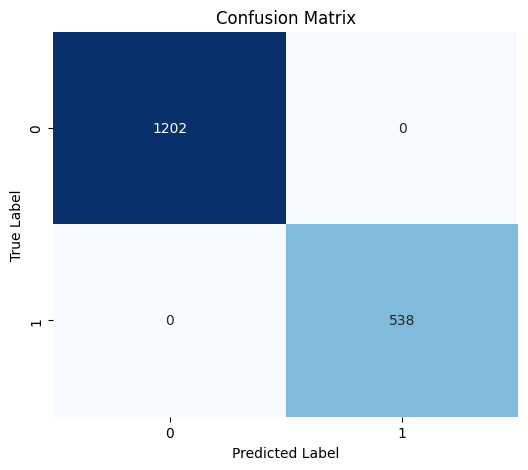

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()